In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")

In [3]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset = dataset.drop(columns=['User ID'])

In [7]:
dataset

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1
...,...,...,...,...
395,46,41000,1,0
396,51,23000,1,1
397,50,20000,1,0
398,36,33000,0,1


In [8]:
dataset.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [9]:
independent = dataset[['Age', 'EstimatedSalary','Gender_Male']]
dependent = dataset[['Purchased']]

In [10]:
dependent.value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [11]:
independent.shape

(400, 3)

In [12]:
dependent.shape

(400, 1)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(independent, dependent, test_size=1/3, random_state=0)

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, criterion='gini', max_features='sqrt', random_state=0)
classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred = classifier.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix

In [33]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[77,  8],
       [ 4, 45]])

In [27]:
from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred)

In [28]:
print(clf_report)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        85
           1       0.85      0.92      0.88        49

    accuracy                           0.91       134
   macro avg       0.90      0.91      0.91       134
weighted avg       0.91      0.91      0.91       134



Text(0, 0.5, 'Actual Label')

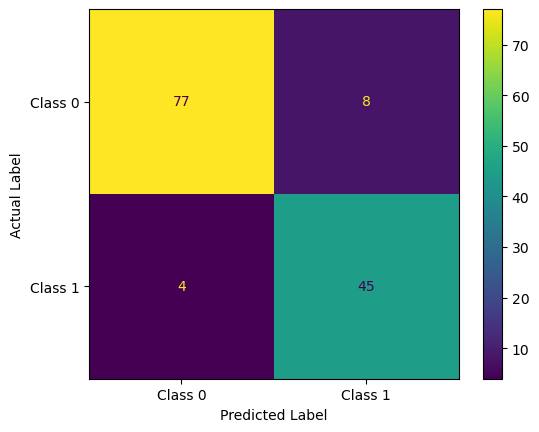

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()
# Set axis labels
disp.ax_.set_xlabel('Predicted Label')
disp.ax_.set_ylabel('Actual Label')

precision class 0 = 77/(77+4) = 0.95
precision class 1 = 45/(45+8) = 0.85

recall class 0 = 77/(77+8) = 0.91
recall class 1 = 45/(45+4) = 0.92

F1 score class 0 = 2*(precision*recall) / (precision+recall) = 2*(0.95*0.91)/(0.95+0.91) =0.93
F1 score class 1 = 2*(0.85*0.92)/(0.85+0.92) = 0.88

Accuracy = (True Positive+True Negative) / All = (77+45)/(77+45+8+4) = 0.91

Recall :(Missed cases) How much percentage of correctly predicted out of Actual value in each section? How much percentage of users can buy the product from the Ad?

Precision:(False Alarm) How much percentage of correctly predicted out of total prediction in each section? what percentage of potential buyers missed to display the Ad?

In [ ]:
#'criterion':{“gini”, “entropy”, “log_loss”}, default=”gini”
#'max_features': “sqrt”, “log2”, None}
#'n_estimators':[10,100]}

In [37]:
classifier = RandomForestClassifier(n_estimators=100, criterion='gini', max_features='sqrt', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
clf_report = classification_report(y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        85
           1       0.85      0.92      0.88        49

    accuracy                           0.91       134
   macro avg       0.90      0.91      0.91       134
weighted avg       0.91      0.91      0.91       134



In [38]:
classifier = RandomForestClassifier(n_estimators=100, criterion='entropy', max_features='sqrt', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
clf_report = classification_report(y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        85
           1       0.86      0.90      0.88        49

    accuracy                           0.91       134
   macro avg       0.90      0.91      0.90       134
weighted avg       0.91      0.91      0.91       134



In [39]:
classifier = RandomForestClassifier(n_estimators=100, criterion='log_loss', max_features='sqrt', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
clf_report = classification_report(y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        85
           1       0.86      0.90      0.88        49

    accuracy                           0.91       134
   macro avg       0.90      0.91      0.90       134
weighted avg       0.91      0.91      0.91       134



In [40]:
classifier = RandomForestClassifier(n_estimators=10, criterion='gini', max_features='sqrt', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
clf_report = classification_report(y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92        85
           1       0.84      0.88      0.86        49

    accuracy                           0.90       134
   macro avg       0.89      0.89      0.89       134
weighted avg       0.90      0.90      0.90       134



In [41]:
classifier = RandomForestClassifier(n_estimators=100, criterion='gini', max_features='log2', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
clf_report = classification_report(y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        85
           1       0.85      0.92      0.88        49

    accuracy                           0.91       134
   macro avg       0.90      0.91      0.91       134
weighted avg       0.91      0.91      0.91       134



In [42]:
classifier.predict([[55,10000,1]])

array([1])

In [43]:
classifier.predict([[55,150000,1]])

array([1])